## Assignment 03 - Deadline: Mar 18, 2026, Wed 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [1]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML

# Set the display option to show all rows scrolling with a slider
pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

# Problem 1: Training ANN on a dataset you choose (100 pts)

(You must use PyTorch in this problem. Answers implemented in TensorFlow will not be accepted.)

Choose a dataset of your choice, other than the Boston Housing dataset, that is suitable for a regression task.

a) Split the dataset into training, validation and test sets. Then standardize the features using StandardScaler() while avoiding data leakage.

b) Build an Artificial Neural Network (ANN) with a reasonable number of hidden layers and neurons.

c) Choose an optimizer and train your model.

d) Plot the training and validation curves. If the validation curve is still decreasing, go back to step (c) and train for more epochs. At this stage, the model should be trained for an excessively large number of epochs so that the validation curve either flattens or starts increasing. Do not stop at the optimal epoch yet; overtrain the model intentionally.

e) Based on the validation curve, determine the epoch at which training should have been stopped. For example, if the validation curve starts to flatten or increase around epoch 40, you should decide that training should have stopped at epoch 40. Do not go back and retrain yet; just identify the appropriate stopping epoch and then proceed to step (f).

f) Retrain the model "from scratch" and stop at the epoch you determined in step (e). This will be your final model. [Here "from scratch" means you should repeat the code that initializes the ANN model before training. If you don't reinitialize the model weights and train, it will not train from scratch, but it will continue training the model you did in step c)]

g) Report the training, validation and test Mean Squared Error (MSE) losses of the final model.

#### Part a)

In [88]:
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn, optim
import torch.nn.functional as F
import time

In [ ]:
dataset = pd.read_csv("../datasets/insurance.csv")
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
X = dataset.drop(columns=["charges"])
y = dataset["charges"]

# Encoding categorical variables
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)  
X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


In [ ]:
# Create indices for the train val test split
train_size = 0.7*len(X_encoded)
val_size = 0.15*len(X_encoded)
test_size = len(X_encoded) - train_size - val_size

# Shuffle the indices
shuffled_indices = np.random.permutation(len(X_encoded))
train_idx = shuffled_indices[:int(train_size)]
val_idx = shuffled_indices[int(train_size):int(train_size) + int(val_size)]
test_idx = shuffled_indices[int(train_size) + int(val_size):]

# Create the train, val, and test sets
X_train = X_encoded.iloc[train_idx]
y_train = y.iloc[train_idx]

X_val = X_encoded.iloc[val_idx]
y_val = y.iloc[val_idx]

X_test = X_encoded.iloc[test_idx]
y_test = y.iloc[test_idx]

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1)).flatten()

# Create TensorDatasets and DataLoaders


train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train_scaled, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32), torch.tensor(y_val_scaled, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test_scaled, dtype=torch.float32))


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) 
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [11]:
ex = next(iter(train_loader))
print("Features batch shape:", ex[0].shape)
print("Target batch shape:", ex[1].shape)
print("First batch of features:\n", ex[0][:5])
print("First batch of targets:\n", ex[1][:5])

Features batch shape: torch.Size([32, 8])
Target batch shape: torch.Size([32])
First batch of features:
 tensor([[-0.9194, -1.1609,  0.6996,  0.9726, -0.5113, -0.5543, -0.5954,  1.7029],
        [ 0.6448,  0.2402,  0.6996, -1.0282, -0.5113, -0.5543, -0.5954, -0.5872],
        [-0.8483, -0.0856,  1.5050,  0.9726, -0.5113, -0.5543, -0.5954,  1.7029],
        [ 1.2846,  1.5549, -0.9113,  0.9726, -0.5113, -0.5543,  1.6794, -0.5872],
        [ 1.7823,  0.4976, -0.9113,  0.9726,  1.9557, -0.5543,  1.6794, -0.5872]])
First batch of targets:
 tensor([-0.8083, -0.2708, -0.7447, -0.1938,  2.7486])


#### Part b)

In [152]:
class RegressionNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers): # Adjustable architecture parameters for maybe later hyperparameter tuning
        super(RegressionNN  , self).__init__()
        self.layer_module = nn.ModuleList()
        
        self.first_layer = nn.Linear(input_size, hidden_size)

        for _ in range(num_layers - 1):
            self.layer_module.append(nn.Linear(hidden_size, hidden_size))
        
        self.output_layer = nn.Linear(hidden_size, 1)


    def forward(self, x):
        x = F.relu(self.first_layer(x))
        for layer in self.layer_module:
            x = F.relu(layer(x))
        x = self.output_layer(x).squeeze(1)
        return x
    
    def __str__(self) -> str:
        return super().__str__()

#### Part c)

In [120]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, early_stopping=False):
    best_model_state = {c: p.clone() for c, p in model.state_dict().items()}  # Initialize best model state

    # Early stopping parameters
    best_val_loss = float('inf')
    last_improvement_epoch = 0
    patience = 10  # Number of epochs to wait for improvement before stopping
    delta = 0.001  # Minimum improvement to be considered as an actual improvement

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        running_train_loss = 0.0
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        running_val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item()
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        if (epoch % 10 == 0 or epoch == num_epochs - 1) and early_stopping:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        if epoch %100 == 0 and not early_stopping:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        

        # Early stopping check and best model state update
        if avg_val_loss < best_val_loss - delta:
            best_val_loss = avg_val_loss
            last_improvement_epoch = epoch
            best_model_state = {c: p.clone() for c, p in model.state_dict().items()}  # Update best model state
        elif epoch - last_improvement_epoch >= patience and early_stopping:
            print("Early stopping triggered.")
            break
            
            
    print(f"Best Validation Loss: {best_val_loss:.4f} at epoch {last_improvement_epoch+1}")
    print("Best model state saved.")
    return train_losses, val_losses, best_model_state, last_improvement_epoch+1


In [140]:
start = time.perf_counter()

model = RegressionNN(input_size=X_train_scaled.shape[1], hidden_size=50, num_layers=5)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=4e-3, momentum=0.9, nesterov=True)


# Training model for 2000 epochs without early stopping to get the full loss curves for visualization and analysis
train_losses, val_losses, global_best_model_state, global_last_improvement_epoch = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=2000, early_stopping=False)

overfit_state_dict = {c: p.clone() for c, p in model.state_dict().items()}  # Clone overfitted model's state to later compare with the early stopped model's state
end = time.perf_counter()
print(f"Training completed in {end - start:.2f} seconds.")


Epoch 1/2000, Train Loss: 1.0166, Val Loss: 1.0686
Epoch 101/2000, Train Loss: 0.0911, Val Loss: 0.2632
Epoch 201/2000, Train Loss: 0.0653, Val Loss: 0.2865
Epoch 301/2000, Train Loss: 0.0449, Val Loss: 0.2801
Epoch 401/2000, Train Loss: 0.0433, Val Loss: 0.3013
Epoch 501/2000, Train Loss: 0.0323, Val Loss: 0.2957
Epoch 601/2000, Train Loss: 0.0214, Val Loss: 0.2776
Epoch 701/2000, Train Loss: 0.0205, Val Loss: 0.3110
Epoch 801/2000, Train Loss: 0.0188, Val Loss: 0.3072
Epoch 901/2000, Train Loss: 0.0332, Val Loss: 0.2934
Epoch 1001/2000, Train Loss: 0.0120, Val Loss: 0.3038
Epoch 1101/2000, Train Loss: 0.0124, Val Loss: 0.3293
Epoch 1201/2000, Train Loss: 0.0111, Val Loss: 0.2992
Epoch 1301/2000, Train Loss: 0.0097, Val Loss: 0.2990
Epoch 1401/2000, Train Loss: 0.0119, Val Loss: 0.2874
Epoch 1501/2000, Train Loss: 0.0146, Val Loss: 0.3167
Epoch 1601/2000, Train Loss: 0.0111, Val Loss: 0.2970
Epoch 1701/2000, Train Loss: 0.0088, Val Loss: 0.3060
Epoch 1801/2000, Train Loss: 0.0128, Val

#### Part d)

The loss curves for validation and Training

C:\Users\baldi\AppData\Local\Temp\ipykernel_604\892420987.py:6: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "ro" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(best_model_idx, val_losses[best_model_idx], 'ro', label='Global Best Model(Lowest Validation Loss)', marker = "*", markersize=10)  # Mark the best model point


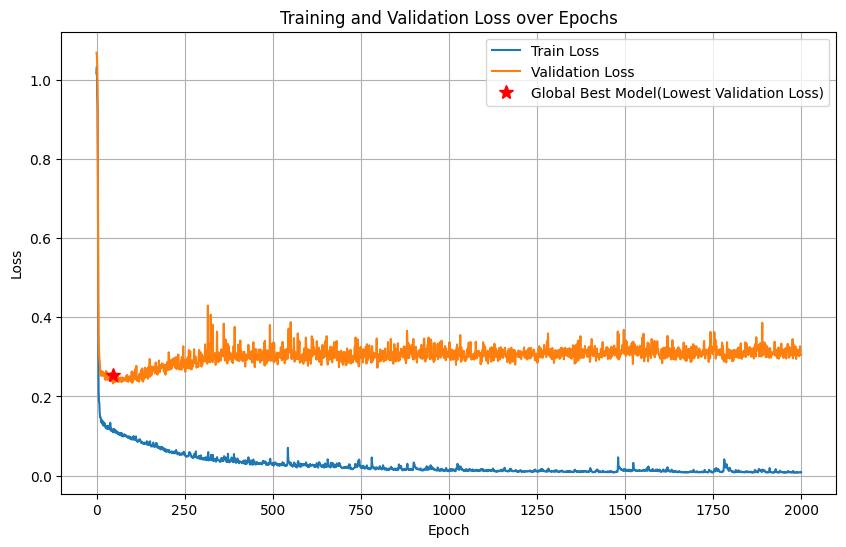

In [141]:
best_model_idx = global_last_improvement_epoch
# Plotting training and validation losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.plot(best_model_idx, val_losses[best_model_idx], 'ro', label='Global Best Model(Lowest Validation Loss)', marker = "*", markersize=10)  # Mark the best model point
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

#### Part e)


##### Determining the early stopping:

After best model is reached and we wait for a little bit longer we should stop training.

How long we should wait is determined by a some parameter, we set before early stopping called patience.

I statically defined this parameter 10.

So we need to stop training at best_model_epoch + 10, and we update best_model_epoch dynamically.

C:\Users\baldi\AppData\Local\Temp\ipykernel_604\259766812.py:8: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "ro" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(best_model_idx, val_losses[best_model_idx], 'ro', label='Global Best Model(Lowest Validation Loss)', marker = "*", markersize=10)  # Mark the best model point


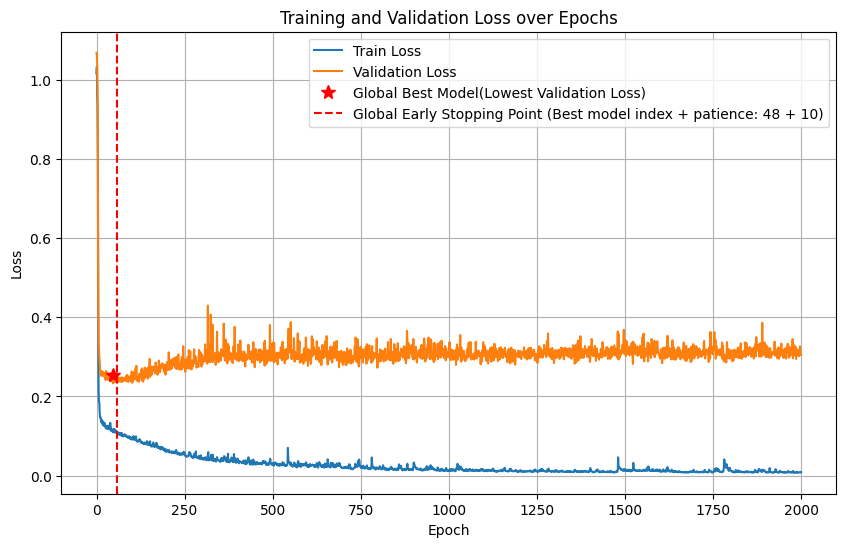

In [142]:
patience = 10
best_model_idx = global_last_improvement_epoch

# Plotting training and validation losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.plot(best_model_idx, val_losses[best_model_idx], 'ro', label='Global Best Model(Lowest Validation Loss)', marker = "*", markersize=10)  # Mark the best model point
plt.axvline(x=best_model_idx + patience, color='r', linestyle='--', label='Global Early Stopping Point (Best model index + patience: {} + {})'.format(best_model_idx, patience))  # Mark the best model epoch
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

#### Part F)

##### Initialise model from scratch and hence train it from scratch.

In [143]:
model = RegressionNN(input_size=X_train_scaled.shape[1], hidden_size=50, num_layers=5)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=4e-3, momentum=0.9, nesterov=True)


# We add early stopping parameter to the function, and this may cause different best model epoch and best model state to be saved, as the training will stop earlier than 2000 epochs if no improvement is observed for 10 consecutive epochs.  
train_losses, val_losses, local_best_model_state, local_last_improvement_epoch = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=2000, early_stopping=True)


Epoch 1/2000, Train Loss: 1.0412, Val Loss: 1.0771
Epoch 11/2000, Train Loss: 0.1561, Val Loss: 0.2824
Epoch 21/2000, Train Loss: 0.1284, Val Loss: 0.2571
Epoch 31/2000, Train Loss: 0.1198, Val Loss: 0.2696
Early stopping triggered.
Best Validation Loss: 0.2516 at epoch 23
Best model state saved.


In [144]:
# Saving the state dict of the model at early stopping point
early_stopped_model_state_dict = {c: p.clone() for c, p in model.state_dict().items()}  # Clone the best model state to avoid in-place modifications

##### Early stop the training.

The reason early stopping happened much earlier (in the epoch 32, not 58) is that we keep our patience 10. And there were no improvement after the epoch 22 for at least 10 epochs. So the early stopping mechanism triggered.

The both stopping epochs can be justified and be chosen instead, I wanted to perform the latter approach.

However since we are tasked to perform the former one, I saved it's state dictionary into variable called **global_best_model_state**, so I performed both of the early stopping approaches.

C:\Users\baldi\AppData\Local\Temp\ipykernel_604\2835704891.py:8: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "ro" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(best_model_idx, val_losses[best_model_idx], 'ro', label='Local Best Model(Lowest Validation Loss)', marker = "*", markersize=10)  # Mark the best model point


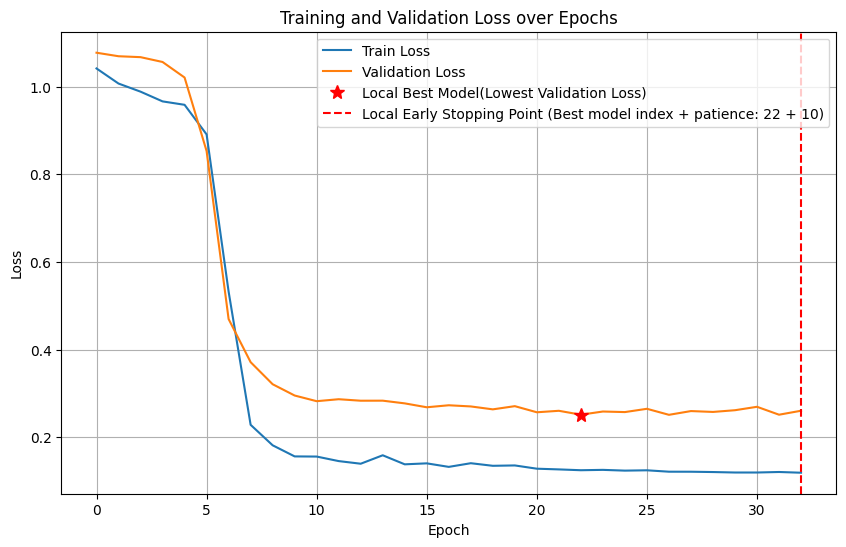

In [145]:
patience = 10
best_model_idx = local_last_improvement_epoch-1

# Plotting training and validation losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.plot(best_model_idx, val_losses[best_model_idx], 'ro', label='Local Best Model(Lowest Validation Loss)', marker = "*", markersize=10)  # Mark the best model point
plt.axvline(x=best_model_idx + patience, color='r', linestyle='--', label='Local Early Stopping Point (Best model index + patience: {} + {})'.format(best_model_idx, patience))  # Mark the best model epoch
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

#### Part g)

In [147]:
# Training, validation, and test MSE losses for the best model
print("Evaluating the final model on training, validation, and test sets...")
overfit_model = RegressionNN(input_size=X_train_scaled.shape[1], hidden_size=50, num_layers=5)
overfit_model.load_state_dict(overfit_state_dict) # The state dict of the model which is trained for 2000 epochs without early stopping

overfit_model.eval() 
with torch.no_grad():
    # Calculate training loss for the best model
    train_outputs = overfit_model(torch.tensor(X_train_scaled, dtype=torch.float32))
    train_loss = criterion(train_outputs, torch.tensor(y_train_scaled, dtype=torch.float32)).item()

    # Calculate validation loss for the best model
    val_outputs = overfit_model(torch.tensor(X_val_scaled, dtype=torch.float32))
    val_loss = criterion(val_outputs, torch.tensor(y_val_scaled, dtype=torch.float32)).item()

    # Calculate test loss for the best model
    test_outputs = overfit_model(torch.tensor(X_test_scaled, dtype=torch.float32))
    test_loss = criterion(test_outputs, torch.tensor(y_test_scaled, dtype=torch.float32)).item()



print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("--"*20)
print("Evaluating the global best model state on training, validation, and test sets...")

global_best = RegressionNN(input_size=X_train_scaled.shape[1], hidden_size=50, num_layers=5)


global_best.load_state_dict(global_best_model_state)
global_best.eval()
with torch.no_grad():
    # Calculate training loss for the best model
    train_outputs = global_best(torch.tensor(X_train_scaled, dtype=torch.float32))
    train_loss = criterion(train_outputs, torch.tensor(y_train_scaled, dtype=torch.float32)).item()

    # Calculate validation loss for the best model
    val_outputs = global_best(torch.tensor(X_val_scaled, dtype=torch.float32))
    val_loss = criterion(val_outputs, torch.tensor(y_val_scaled, dtype=torch.float32)).item()

    # Calculate test loss for the best model
    test_outputs = global_best(torch.tensor(X_test_scaled, dtype=torch.float32))
    test_loss = criterion(test_outputs, torch.tensor(y_test_scaled, dtype=torch.float32)).item()


print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("--"*20)
print("Evaluating the local best model state on training, validation, and test sets...")

local_best = RegressionNN(input_size=X_train_scaled.shape[1], hidden_size=50, num_layers=5)


local_best.load_state_dict(local_best_model_state)
local_best.eval()
with torch.no_grad():
    # Calculate training loss for the best model
    train_outputs = local_best(torch.tensor(X_train_scaled, dtype=torch.float32))
    train_loss = criterion(train_outputs, torch.tensor(y_train_scaled, dtype=torch.float32)).item()

    # Calculate validation loss for the best model
    val_outputs = local_best(torch.tensor(X_val_scaled, dtype=torch.float32))
    val_loss = criterion(val_outputs, torch.tensor(y_val_scaled, dtype=torch.float32)).item()

    # Calculate test loss for the best model
    test_outputs = local_best(torch.tensor(X_test_scaled, dtype=torch.float32))
    test_loss = criterion(test_outputs, torch.tensor(y_test_scaled, dtype=torch.float32)).item()


print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Evaluating the final model on training, validation, and test sets...
Training Loss: 0.0077
Validation Loss: 0.2496
Test Loss: 0.2173
----------------------------------------
Evaluating the global best model state on training, validation, and test sets...
Training Loss: 0.1100
Validation Loss: 0.1948
Test Loss: 0.1568
----------------------------------------
Evaluating the local best model state on training, validation, and test sets...
Training Loss: 0.1293
Validation Loss: 0.1992
Test Loss: 0.1572
